<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
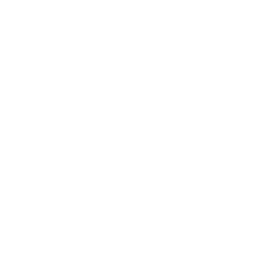
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Προφίλ Κινδύνου Πελατών μέσω Κανονικής Διάκρισης</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Χρηματοοικονομικές Υπηρεσίες / Ανάλυση Πιστωτικού Κινδύνου &nbsp;|&nbsp; Μάρτιος 2026</p>
</div>
</div>
</div>

## Σύνοψη για τη Διοίκηση

Τρεις ομάδες κατάστασης δανείου σε ένα χαρτοφυλάκιο στεγαστικών δανείων ιδιωτών — **defaulted**, **current** και **prepaid** — διαφέρουν ταυτόχρονα σε αρκετές διαστάσεις χρηματοοικονομικής υγείας, γεγονός που καθιστά κάθε μεμονωμένο δείκτη αδύναμο σήμα κινδύνου. Αυτό το notebook εφαρμόζει το **PROC CANDISC** (κανονική διακριτική ανάλυση) σε ένα δείγμα αναθεώρησης κινδύνου 100 πελατών, συμπυκνώνοντας έξι συσχετισμένους χρηματοοικονομικούς δείκτες σε δύο κανονικές διαστάσεις που μεγιστοποιούν τον διαχωρισμό μεταξύ των τριών ομάδων κατάστασης.

Η πρώτη κανονική διάσταση φέρει σχεδόν όλον τον διαχωρισμό μεταξύ των ομάδων — κανονική συσχέτιση **0.958**, μοιραζόμενη το **91.8%** της διακύμανσής της με την ένταξη σε ομάδα — και ταξινομεί τους δανειολήπτες με σαφήνεια από τους defaulted στο ένα άκρο έως τους prepaid στο άλλο. Η δεύτερη διάσταση (κανονική συσχέτιση **0.503**, στο τετράγωνο **0.254**) προσθέτει μια δευτερεύουσα αντίθεση που καθοδηγείται από το ιστορικό καθυστερήσεων και τη μόχλευση. Οι τετραγωνισμένες αποστάσεις Mahalanobis επιβεβαιώνουν ότι τα κεντροειδή **DEFAULT** και **PREPAID** αποτελούν το πιο ευρέως διαχωρισμένο ζεύγος (**75.3**), με το **CURRENT** να βρίσκεται ανάμεσά τους (34.3 από το DEFAULT, 10.1 από το PREPAID). Οι προκύπτουσες κανονικές βαθμολογίες σχηματίζουν έναν συμπαγή σύνθετο δείκτη κινδύνου κατάλληλο για τμηματοποίηση χαρτοφυλακίου και βαθμονόμηση scorecard.

## Πηγές Δεδομένων

| Πηγή | Περιγραφή | Εγγραφές |
|--------|-------------|--------|
| WORK.LOAN_PROFILES | Συνθετικοί χρηματοοικονομικοί δείκτες και μετρικές συμπεριφοράς πελατών, με ετικέτα κατά κατάσταση δανείου, ληφθέντες ως ισορροπημένο δείγμα αναθεώρησης κινδύνου | 100 |

Το δείγμα υπερεκπροσωπεί σκόπιμα τους λογαριασμούς defaulted και prepaid (μια δειγματοληψία τύπου case–control) ώστε κάθε ομάδα κατάστασης να είναι αρκετά μεγάλη για την εκτίμηση μιας σταθερής δομής συνδιακύμανσης εντός ομάδας για τη διακριτική ανάλυση.

---

In [1]:
/* --------------------------------------------------------
   Generate a synthetic loan-customer risk-review sample.
   Three status groups (DEFAULT / CURRENT / PREPAID) are
   over-sampled toward the risk tails so each class is large
   enough for a stable within-group covariance estimate.
   -------------------------------------------------------- */
ΔΕΔΟΜΕΝΑ work.loan_profiles;
    CALL streaminit(42);
    LENGTH loan_status $10 vintage $7 customer_id $12;
    ARRAY statuses[3] $10 _temporary_ ('DEFAULT' 'CURRENT' 'PREPAID');
    ARRAY vintages[4] $7 _temporary_ ('2022-Q1' '2022-Q3' '2023-Q1' '2023-Q3');
    ΕΠΑΝΑΛΗΨΗ i = 1 ΕΩΣ 20000;
        customer_id = cat('CUST-', PUT(i, z6.));
        vintage = vintages[int(rand('uniform') * 4) + 1];
        status_prob = rand('uniform');
        ΕΑΝ status_prob < 0.30 ΤΟΤΕ status_idx = 1;       /* DEFAULT */
        ΑΛΛΙΩΣ ΕΑΝ status_prob < 0.70 ΤΟΤΕ status_idx = 2;  /* CURRENT */
        ΑΛΛΙΩΣ status_idx = 3;                             /* PREPAID */
        loan_status = statuses[status_idx];
        /* Financial ratios separate the three status groups */
        ΕΑΝ loan_status = 'DEFAULT' ΤΟΤΕ ΕΠΑΝΑΛΗΨΗ;
            dti_ratio          = rand('normal', 0.58, 0.12);
            ltv_ratio          = rand('normal', 0.92, 0.10);
            payment_to_income  = rand('normal', 0.42, 0.08);
            credit_utilization = rand('normal', 0.85, 0.10);
            months_delinquent  = int(rand('exponential') * 4) + 1;
            savings_balance    = rand('exponential') * 4000 + 200;
        ΤΕΛΟΣ;
        ΑΛΛΙΩΣ ΕΑΝ loan_status = 'CURRENT' ΤΟΤΕ ΕΠΑΝΑΛΗΨΗ;
            dti_ratio          = rand('normal', 0.35, 0.10);
            ltv_ratio          = rand('normal', 0.78, 0.09);
            payment_to_income  = rand('normal', 0.28, 0.07);
            credit_utilization = rand('normal', 0.45, 0.15);
            months_delinquent  = 0;
            savings_balance    = rand('exponential') * 8000 + 200;
        ΤΕΛΟΣ;
        ΑΛΛΙΩΣ ΕΠΑΝΑΛΗΨΗ;
            dti_ratio          = rand('normal', 0.22, 0.07);
            ltv_ratio          = rand('normal', 0.60, 0.12);
            payment_to_income  = rand('normal', 0.20, 0.05);
            credit_utilization = rand('normal', 0.25, 0.12);
            months_delinquent  = 0;
            savings_balance    = rand('exponential') * 16000 + 500;
        ΤΕΛΟΣ;
        /* Round and constrain ratios to valid ranges */
        dti_ratio          = round(dti_ratio, 0.001);
        ltv_ratio          = round(ltv_ratio, 0.001);
        payment_to_income  = round(payment_to_income, 0.001);
        credit_utilization = round(credit_utilization, 0.001);
        savings_balance    = round(savings_balance, 0.01);
        ΕΑΝ dti_ratio < 0.05 ΤΟΤΕ dti_ratio = 0.05;
        ΕΑΝ dti_ratio > 0.99 ΤΟΤΕ dti_ratio = 0.99;
        ΕΑΝ ltv_ratio < 0.10 ΤΟΤΕ ltv_ratio = 0.10;
        ΕΑΝ ltv_ratio > 1.20 ΤΟΤΕ ltv_ratio = 1.20;
        ΕΑΝ credit_utilization < 0.01 ΤΟΤΕ credit_utilization = 0.01;
        ΕΑΝ credit_utilization > 0.99 ΤΟΤΕ credit_utilization = 0.99;
        ΕΞΟΔΟΣ;
    ΤΕΛΟΣ;
   ΕΤΙΚΕΤΑ loan_status='Κατάσταση δανείου' vintage='Χρονιά χορήγησης'
         dti_ratio='Λόγος χρέους προς εισόδημα' ltv_ratio='Λόγος δανείου προς αξία'
         payment_to_income='Λόγος πληρωμής προς εισόδημα' credit_utilization='Χρήση πίστωσης'
         savings_balance='Υπόλοιπο αποταμίευσης' months_delinquent='Μήνες καθυστέρησης';
    ΑΦΑΙΡΕΣΗ i status_prob status_idx;
ΕΚΤΕΛΕΣΗ;


NOTE: DATA work.loan_profiles

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.loan_profiles (100 rows, 9 columns).
NOTE: DATA elapsed:
  wall  7.23 seconds
  cpu   7.23 seconds


---

### Βασικά προφίλ ομάδων

Πριν από τη συμπύκνωση των δεικτών, συνοψίστε πώς διαφέρουν οι τρεις ομάδες κατάστασης μία μεταβλητή τη φορά, και επιβεβαιώστε τη σύνθεση του δείγματος στις διάφορες χρονιές χορήγησης.

                            Βασικές Κατανομές Χρηματοοικονομικών Λόγων ανά Κατάσταση Δανείου                            

                                                  The MEANS Procedure

                    Analysis Variable : dti_ratio Λόγος χρέους προς εισόδημα

        Κατάσταση δανείου                          N Obs           Mean        Std Dev
        ------------------------------------------------------------------------------
        CURRENT                                       46          0.331          0.112
        DEFAULT                                       29          0.570          0.114
        PREPAID                                       25          0.216          0.056
        ------------------------------------------------------------------------------

                       Analysis Variable : ltv_ratio Λόγος δανείου προς αξία

        Κατάσταση δανείου                          N Obs           Mean        Std Dev
        ---------------------------------


NOTE: Option TITLE changed to Βασικές Κατανομές Χρηματοοικονομικών Λόγων ανά Κατάσταση Δανείου.
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: Option TITLE changed to Σύνθεση Δείγματος ανά Χρονιά Χορήγησης και Κατάσταση.
NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_vintage_loan_status.spec.json
NOTE: PROC FREQ statement used.


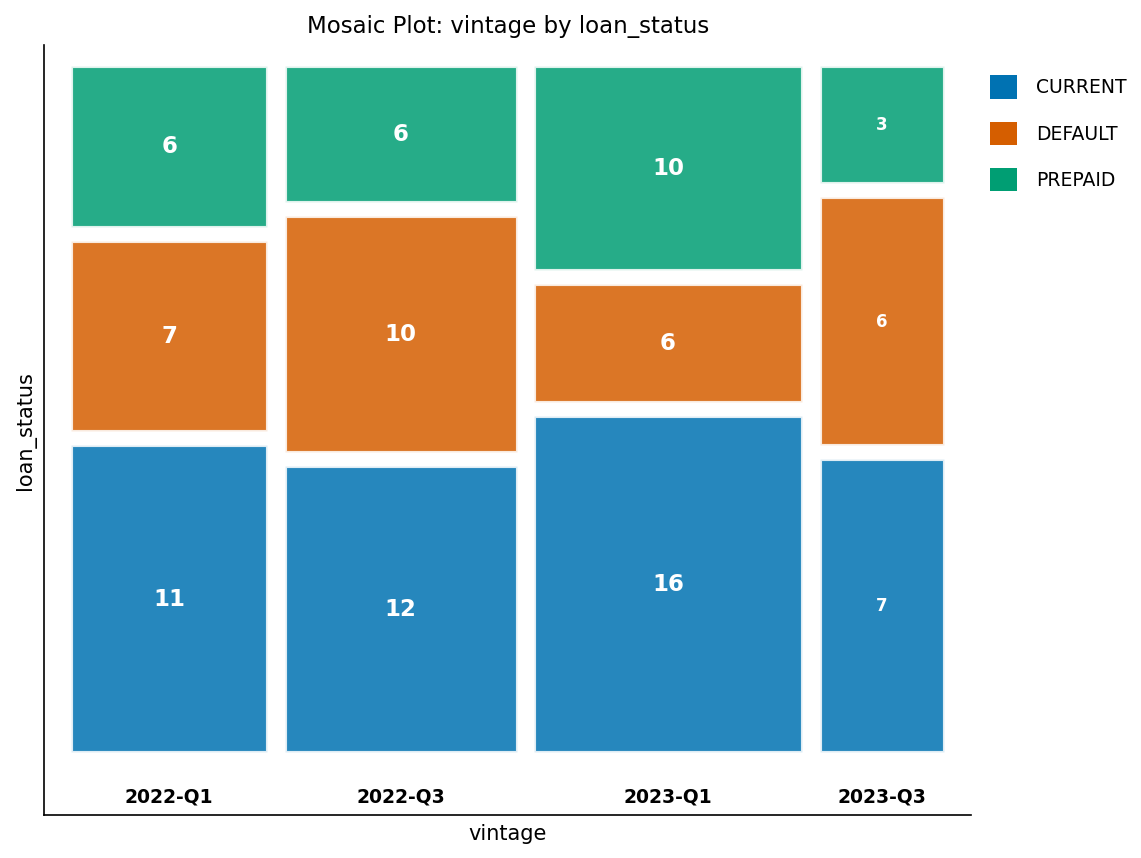

In [2]:
/* --------------------------------------------------------
   Baseline financial-ratio distributions by loan status
   -------------------------------------------------------- */
TITLE 'Βασικές Κατανομές Χρηματοοικονομικών Λόγων ανά Κατάσταση Δανείου';
ΔΙΑΔΙΚΑΣΙΑ ΜΕΣΟΙ ΔΕΔΟΜΕΝΑ=work.loan_profiles n mean std maxdec=3;
    ΚΛΑΣΗ loan_status;
    ΜΕΤΑΒΛΗΤΗ dti_ratio ltv_ratio payment_to_income credit_utilization
        savings_balance months_delinquent;
ΕΚΤΕΛΕΣΗ;

/* --------------------------------------------------------
   Sample composition by vintage and status
   -------------------------------------------------------- */
TITLE 'Σύνθεση Δείγματος ανά Χρονιά Χορήγησης και Κατάσταση';
ΔΙΑΔΙΚΑΣΙΑ ΣΥΧΝΟΤΗΤΕΣ ΔΕΔΟΜΕΝΑ=work.loan_profiles;
    TABLES vintage * loan_status / nocum nopercent;
ΕΚΤΕΛΕΣΗ;

---

### Κανονική διακριτική ανάλυση

Προσαρμόστε ένα ενιαίο συγκεντρωτικό μοντέλο κανονικής διάκρισης σε όλους τους 100 πελάτες. Το `OUT=` γράφει τις κανονικές βαθμολογίες ανά πελάτη, το `OUTSTAT=` καταγράφει την κανονική δομή, τα κεντροειδή των κλάσεων και τις τετραγωνισμένες αποστάσεις Mahalanobis, και το `DISTANCE` ζητά τις αποστάσεις μεταξύ των ομάδων. Η διαφημιζόμενη διαδικασία εδώ είναι ακριβώς αυτή που εκτελείται: **PROC CANDISC**.

                                  Σύνθεση Δείγματος ανά Χρονιά Χορήγησης και Κατάσταση                                  




NOTE: ODS OUTPUT: CANONICALCORRELATIONS -> can_corr
NOTE: PROC CANDISC data=work.loan_profiles ncan=Some(2) prefix=Can

NOTE: Using Python/scikit-learn for canonical discriminant analysis
NOTE: Number of Observations: 100
NOTE: Number of Classes: 3
NOTE: Class Level Information:
NOTE:   CURRENT: 46
NOTE:   DEFAULT: 29
NOTE:   PREPAID: 25
NOTE: Canonical Correlations:
NOTE:   Can1: 0.958136
NOTE:   Can2: 0.503509
NOTE: Eigenvalues of Inv(E)*H:
NOTE:                          Canonical  Approximate  Squared
NOTE:               Eigenvalue Correlation  Std Error Correlation
NOTE:   Can1       11.198645    0.958136            0.918024
NOTE:   Can2        0.339624    0.503509            0.253522
NOTE: Multivariate Statistics and F Approximations:
NOTE:   Statistic                Value     F Value  Num DF  Den DF  Pr > F
NOTE:   Wilks' Lambda         0.061194     46.65      12   184.0   0.0000
NOTE:   Pillai's Trace        1.171545     21.68      12   184.0   0.0000
NOTE:   Hotelling-Lawley  

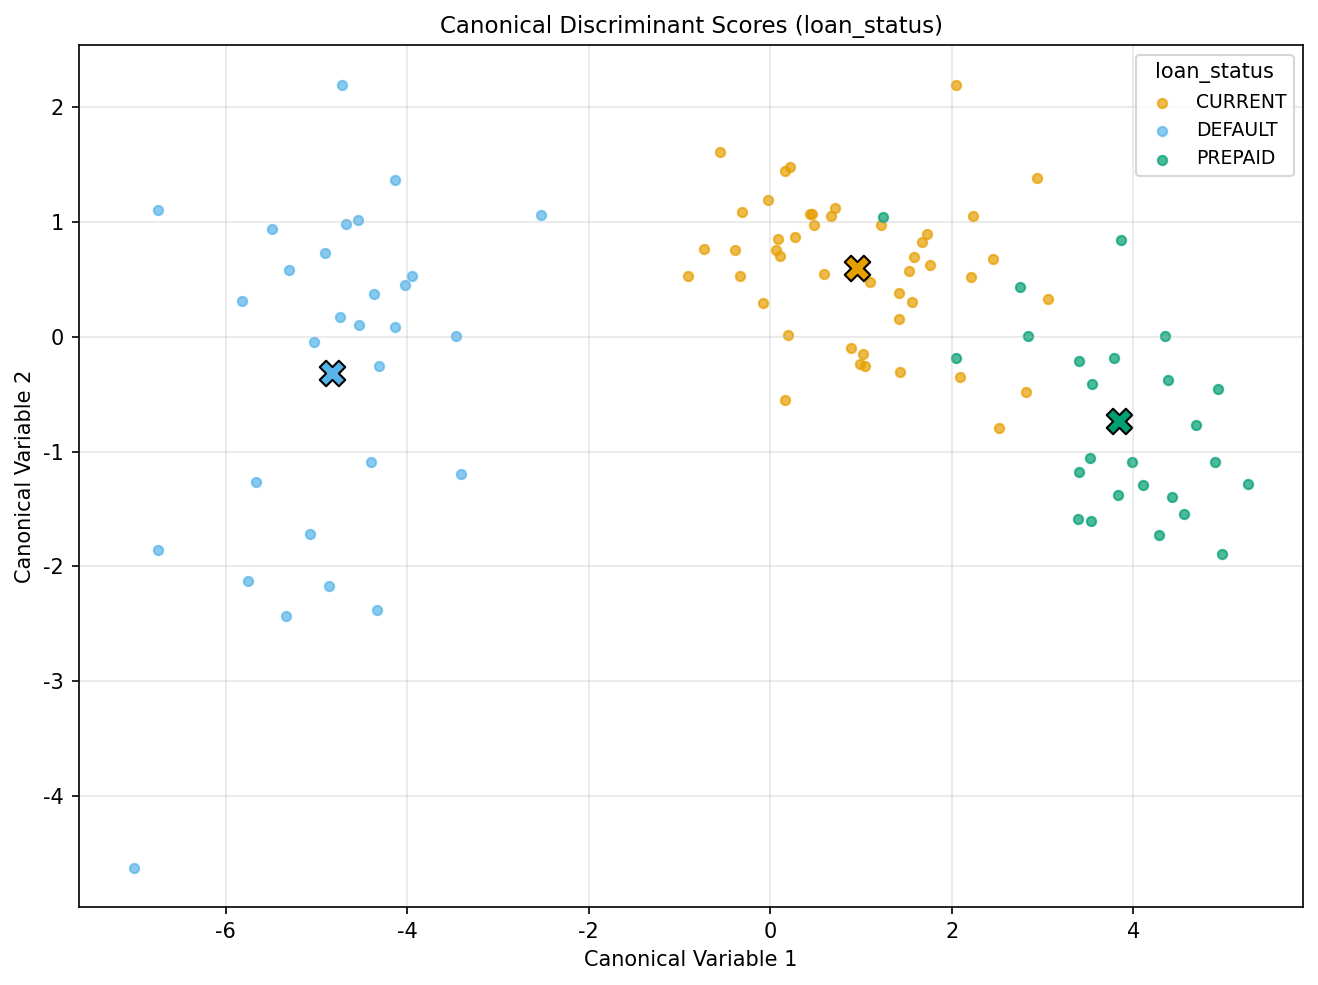

In [3]:
/* --------------------------------------------------------
   Canonical discriminant analysis of loan-status groups.
   OUT=    per-customer canonical scores (Can1, Can2)
   OUTSTAT= structure, class means, Mahalanobis distances
   -------------------------------------------------------- */
ODS ΕΞΟΔΟΣ CanonicalCorrelations=work.can_corr;

ΔΙΑΔΙΚΑΣΙΑ CANDISC ΔΕΔΟΜΕΝΑ=work.loan_profiles
    out=work.risk_scores
    OUTSTAT=work.can_stat
    ncan=2
    distance;
    ΚΛΑΣΗ loan_status;
    ΜΕΤΑΒΛΗΤΗ dti_ratio ltv_ratio payment_to_income credit_utilization
        savings_balance months_delinquent;
    TITLE 'Κανονική Διάκριση Κινδύνου των Ομάδων Κατάστασης Δανείου';
ΕΚΤΕΛΕΣΗ;

ODS ΕΞΟΔΟΣ CLOSE;

---

### Κανονικές συσχετίσεις

Πόσο από τον διαχωρισμό μεταξύ των τριών ομάδων συλλαμβάνει κάθε κανονική διάσταση.

In [4]:
ΔΙΑΔΙΚΑΣΙΑ ΕΚΤΥΠΩΣΗ ΔΕΔΟΜΕΝΑ=work.can_corr noobs;
    TITLE 'Κανονικές Συσχετίσεις';
ΕΚΤΕΛΕΣΗ;

                                                 Κανονικές Συσχετίσεις                                                  

CANONICAL_VARIABLE  CANONICAL_CORRELATION  SQUARED_CANONICAL_CORRELATION     EIGENVALUE
Can1                         0.9581355246                   0.9180236835  11.1986452089
Can2                          0.503509317                   0.2535216323   0.3396235488




NOTE: PROC PRINT data=work.can_corr

NOTE: PROC PRINT completed: 2 observations printed, 4 variables


### Κανονική δομή (φορτίσεις μεταβλητών)

Η συσχέτιση κάθε αρχικού χρηματοοικονομικού δείκτη με τις δύο κανονικές διαστάσεις — έτσι ερμηνεύονται οι διαστάσεις.

In [5]:
ΔΙΑΔΙΚΑΣΙΑ ΕΚΤΥΠΩΣΗ ΔΕΔΟΜΕΝΑ=work.can_stat noobs;
    ΟΠΟΥ _type_ = 'STRUCTUR';
    ΜΕΤΑΒΛΗΤΗ _name_ Can1 Can2;
    TITLE 'Συγκεντρωτική Ενδο-ομαδική Κανονική Δομή';
ΕΚΤΕΛΕΣΗ;

                                        Συγκεντρωτική Ενδο-ομαδική Κανονική Δομή                                        

            _NAME_       CAN1       CAN2
dti_ratio           -0.403583  -0.022755
ltv_ratio           -0.369749   0.732657
payment_to_income   -0.304192   0.117008
credit_utilization  -0.595076  -0.056264
savings_balance       0.12558   0.093182
months_delinquent   -0.323965  -0.699884




NOTE: PROC PRINT data=work.can_stat

NOTE: PROC PRINT completed: 6 observations printed, 3 variables


### Κεντροειδή ομάδων και αποστάσεις Mahalanobis

Οι μέσοι των κλάσεων στους κανονικούς άξονες (τα κεντροειδή των ομάδων) και οι τετραγωνισμένες αποστάσεις Mahalanobis μεταξύ κάθε ζεύγους ομάδων — η βάση για τη βαθμονόμηση της βαθμολογίας κινδύνου.

In [6]:
ΔΙΑΔΙΚΑΣΙΑ ΕΚΤΥΠΩΣΗ ΔΕΔΟΜΕΝΑ=work.can_stat noobs;
    ΟΠΟΥ _type_ IN ('CANMEAN' 'DIST');
    ΜΕΤΑΒΛΗΤΗ _type_ _name_ Can1 Can2;
    TITLE 'Κεντροειδή Ομάδων (CANMEAN) και Τετραγωνικές Αποστάσεις Mahalanobis (DIST)';
ΕΚΤΕΛΕΣΗ;

                       Κεντροειδή Ομάδων (CANMEAN) και Τετραγωνικές Αποστάσεις Mahalanobis (DIST)                       

 _TYPE_              _NAME_       CAN1       CAN2
CANMEAN  CURRENT              0.956102    0.59917
CANMEAN  DEFAULT             -4.826727  -0.316237
CANMEAN  PREPAID              3.839776  -0.735639
DIST     CURRENT to DEFAULT  34.279058          .
DIST     CURRENT to PREPAID  10.097273          .
DIST     DEFAULT to PREPAID  75.284092          .




NOTE: PROC PRINT data=work.can_stat

NOTE: PROC PRINT completed: 6 observations printed, 4 variables


---

### Χάρτης κανονικής διάκρισης

Κάθε πελάτης απεικονίζεται στον δισδιάστατο κανονικό χώρο, με χρωματισμό ανά κατάσταση δανείου. Οι καλά διαχωρισμένες συστάδες υποδεικνύουν ότι οι κανονικές βαθμολογίες φέρουν ισχυρή πληροφορία ομάδας.

                       Κεντροειδή Ομάδων (CANMEAN) και Τετραγωνικές Αποστάσεις Mahalanobis (DIST)                       




NOTE: PROC SGPLOT data=work.risk_scores

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


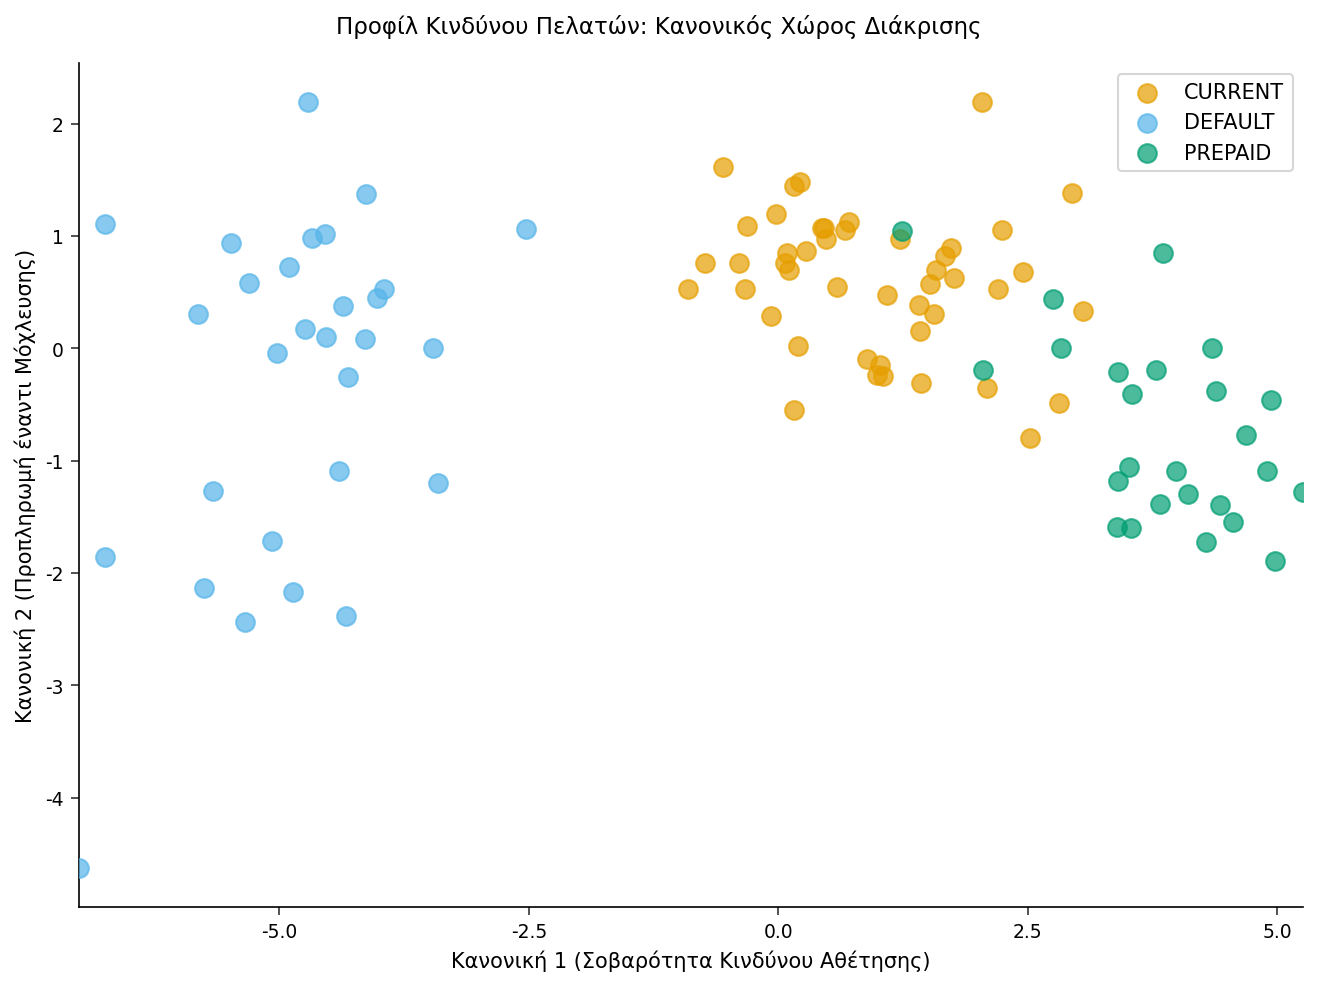

In [7]:
ΔΙΑΔΙΚΑΣΙΑ SGPLOT ΔΕΔΟΜΕΝΑ=work.risk_scores;
    SCATTER x=Can1 y=Can2 / GROUP=loan_status
        MARKERATTRS=(SYMBOL=circlefilled size=9)
        TRANSPARENCY=0.3;
    XAXIS ΕΤΙΚΕΤΑ='Κανονική 1 (Σοβαρότητα Κινδύνου Αθέτησης)';
    YAXIS ΕΤΙΚΕΤΑ='Κανονική 2 (Προπληρωμή έναντι Μόχλευσης)';
    TITLE 'Προφίλ Κινδύνου Πελατών: Κανονικός Χώρος Διάκρισης';
ΕΚΤΕΛΕΣΗ;

---

### Ερμηνεία

Οι δύο κανονικές διαστάσεις διαχωρίζουν με σαφήνεια τις τρεις ομάδες κατάστασης δανείου εντός αυτού του δείγματος 100 πελατών (46 current, 29 defaulted, 25 prepaid).

**Διάσταση 1 — σοβαρότητα κινδύνου αθέτησης (κανονική συσχέτιση 0.958, 91.8% κοινή διακύμανση).** Αυτός ο άξονας από μόνος του ερμηνεύει τη συντριπτική πλειοψηφία του διαχωρισμού των ομάδων (ιδιοτιμή 11.20 έναντι 0.34 για τον δεύτερο άξονα). Στη συγκεντρωτική κανονική δομή εντός κλάσεων φορτίζει ισχυρότερα στην αξιοποίηση πίστωσης (-0.595), στον λόγο χρέους προς εισόδημα (-0.404), στον LTV (-0.370), στους μήνες καθυστέρησης (-0.324) και στον λόγο πληρωμής προς εισόδημα (-0.304) — κάθε μέτρο μόχλευσης και επιβάρυνσης δείχνει προς την ίδια κατεύθυνση. Επειδή οι φορτίσεις είναι αρνητικές, οι χαμηλές (πιο αρνητικές) βαθμολογίες Can1 σηματοδοτούν τους δανειολήπτες υψηλότερου κινδύνου. Τα κεντροειδή των κλάσεων το επιβεβαιώνουν: οι λογαριασμοί defaulted βρίσκονται στο Can1 = -4.83, οι current στο +0.96 και οι prepaid στο +3.84, μια καθαρή μονοτονική ταξινόμηση από τη χειρότερη έως την καλύτερη πιστωτική υγεία.

**Διάσταση 2 — μόχλευση έναντι καθυστέρησης (κανονική συσχέτιση 0.503).** Ο δεύτερος άξονας αντιπαραβάλλει τον λόγο LTV (+0.733) με τους μήνες καθυστέρησης (-0.700): διαχωρίζει τους δανειολήπτες που είναι έντονα μοχλευμένοι αλλά ενήμεροι από εκείνους που φέρουν καθυστέρηση. Βελτιώνει την εικόνα εντός του Can1 αλλά συνεισφέρει πολύ λιγότερο διαχωρισμό, όπως δείχνουν τα σχεδόν ίσα κεντροειδή Can2 για τις εξυπηρετούμενες ομάδες (current +0.599, prepaid -0.736).

**Διαχωρισμός ομάδων.** Οι τετραγωνισμένες αποστάσεις Mahalanobis μεταξύ των μέσων των κλάσεων ποσοτικοποιούν τα κενά: το DEFAULT-προς-PREPAID είναι το μεγαλύτερο στο 75.3, το DEFAULT-προς-CURRENT είναι 34.3 και το CURRENT-προς-PREPAID είναι το μικρότερο στο 10.1. Οι δύο εξυπηρετούμενες ομάδες είναι επομένως πιο κοντά η μία στην άλλη απ' ό,τι καθεμία στην ομάδα defaulted, ακριβώς όπως θα ανέμενε ένας δανειστής.

**Πρακτική χρήση.** Η πρώτη κανονική βαθμολογία συμπεριφέρεται σαν έτοιμος σύνθετος δείκτης κινδύνου: συμπιέζει έξι συσχετισμένους δείκτες σε μία καλά διαχωρισμένη διάσταση που ταξινομεί τους πελάτες από τον υψηλότερο έως τον χαμηλότερο κίνδυνο αθέτησης. Οι ομάδες χαρτοφυλακίου μπορούν να τμηματοποιήσουν με βάση σημεία αποκοπής του Can1, και οι αποστάσεις Mahalanobis δίνουν μια θεμελιωμένη βάση για την ανάθεση ενός νέου αιτούντος στην πλησιέστερη ομάδα κατάστασης κατά τη βαθμονόμηση του scorecard.

---

### Εξαγωγή για τη μηχανή βαθμολόγησης

Διατηρήστε τις κανονικές βαθμολογίες ανά πελάτη και το σύνολο δεδομένων κανονικών στατιστικών (το οποίο φέρει τα κεντροειδή και τις αποστάσεις Mahalanobis) για την επακόλουθη βαθμονόμηση του scorecard.

In [8]:
/* --------------------------------------------------------
   Export canonical risk scores and canonical statistics
   -------------------------------------------------------- */
ΔΙΑΔΙΚΑΣΙΑ EXPORT ΔΕΔΟΜΕΝΑ=work.risk_scores
    OUTFILE='customer_risk_canonical_scores.csv'
    DBMS=csv REPLACE;
ΕΚΤΕΛΕΣΗ;

ΔΙΑΔΙΚΑΣΙΑ EXPORT ΔΕΔΟΜΕΝΑ=work.can_stat
    OUTFILE='canonical_statistics.csv'
    DBMS=csv REPLACE;
ΕΚΤΕΛΕΣΗ;


NOTE: PROC EXPORT data=work.risk_scores outfile=customer_risk_canonical_scores.csv

NOTE: Exported 100 rows to customer_risk_canonical_scores.csv.
NOTE: PROC EXPORT data=work.can_stat outfile=canonical_statistics.csv

NOTE: Exported 31 rows to canonical_statistics.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Εμπιστευτικό
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Με την υποστήριξη του <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>